In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.metrics import roc_curve, auc

sns.set_theme(style="whitegrid", context="paper", font_scale=1.25)
COLOR_MAIN   = "#4C72B0"
COLOR_HIGH   = "#2ca02c"
COLOR_LOW    = "#d62728"
COLOR_LINE   = "#e05c00"

df = pd.read_json("final_dataset_tqs.json")
df = df.dropna(subset=["mutation_score", "tqs"]).copy()
df["assert_count"] = df["assert_types"].apply(lambda x: len(x) if isinstance(x, list) else 0)

r,   p_r  = stats.pearsonr(df["tqs"], df["mutation_score"])
rho, p_s  = stats.spearmanr(df["tqs"], df["mutation_score"])
tau, p_t  = stats.kendalltau(df["tqs"], df["mutation_score"])

summary = pd.DataFrame({
    "Métrica":    ["Pearson r", "Spearman ρ", "Kendall τ"],
    "Valor":      [round(r,4),  round(rho,4), round(tau,4)],
    "p-value":    [round(p_r,4),round(p_s,4), round(p_t,4)],
    "Significativo (α=0.05)": [p_r<0.05, p_s<0.05, p_t<0.05]
})

print(f"Dataset: n={len(df)} entradas")
print(f"TQS  — [{df.tqs.min():.2f}, {df.tqs.max():.2f}]   média={df.tqs.mean():.2f}")
print(f"MS   — [{df.mutation_score.min():.3f}, {df.mutation_score.max():.3f}]  média={df.mutation_score.mean():.3f}\n")
display(summary)

Dataset: n=51 entradas
TQS  — [1.50, 7.00]   média=4.55
MS   — [0.000, 1.000]  média=0.833



,Métrica,Valor,p-value,Significativo (α=0.05)
0,Pearson r,0.4756,0.0004,True
1,Spearman ρ,0.2795,0.0470,True
2,Kendall τ,0.2356,0.0323,True


## Fig. 1 — Scatter plot with regression line and confidence interval
Colored by the number of assertion types: darker points = greater diversity of assertions.

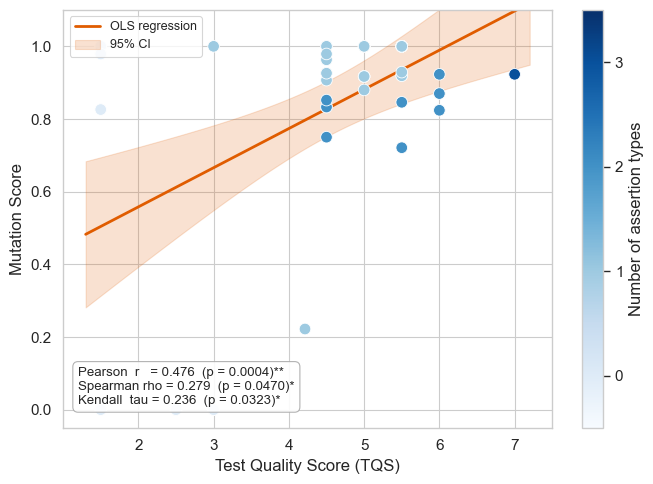

In [2]:
fig, ax = plt.subplots(figsize=(7, 5))

sc = ax.scatter(
    df["tqs"], df["mutation_score"],
    c=df["assert_count"], cmap="Blues", vmin=-0.5, vmax=3.5,
    s=70, edgecolors="white", linewidths=0.6, zorder=3
)
plt.colorbar(sc, ax=ax, label="Number of assertion types", ticks=[0, 1, 2, 3])

m_fit, b_fit, *_ = stats.linregress(df["tqs"], df["mutation_score"])
x_line = np.linspace(df["tqs"].min() - 0.2, df["tqs"].max() + 0.2, 200)
y_line = m_fit * x_line + b_fit

n = len(df)
se = np.sqrt(np.sum((df["mutation_score"] - (m_fit * df["tqs"] + b_fit)) ** 2) / (n - 2))
x_mean = df["tqs"].mean()
s_xx = np.sum((df["tqs"] - x_mean) ** 2)
ci = stats.t.ppf(0.975, df=n - 2) * se * np.sqrt(1 / n + (x_line - x_mean) ** 2 / s_xx)

ax.plot(x_line, y_line, color=COLOR_LINE, linewidth=2, label="OLS regression")
ax.fill_between(x_line, y_line - ci, y_line + ci, alpha=0.18, color=COLOR_LINE, label="95% CI")

stats_text = (
    "Pearson  r   = {:.3f}  (p = {:.4f})**\n"
    "Spearman rho = {:.3f}  (p = {:.4f})*\n"
    "Kendall  tau = {:.3f}  (p = {:.4f})*"
).format(r, p_r, rho, p_s, tau, p_t)
ax.text(0.03, 0.05, stats_text, transform=ax.transAxes, fontsize=9.5,
        verticalalignment="bottom",
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#aaaaaa", alpha=0.9))

ax.set_xlabel("Test Quality Score (TQS)")
ax.set_ylabel("Mutation Score")
ax.set_ylim(-0.05, 1.10)
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("fig1_scatter.pdf", dpi=300, bbox_inches="tight")
plt.show()


## ROC Curve: TQS as a Predictor of High-Quality Tests (MS ≥ 0.90)
Evaluates TQS as a binary classifier: AUC > 0.5 = better than random.

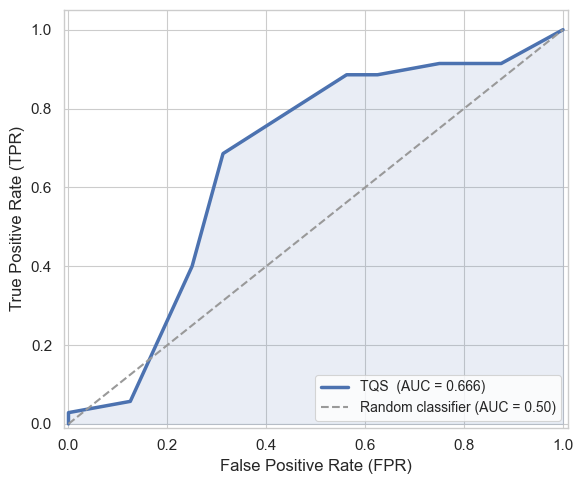

AUC = 0.6661  |  Positives (MS>=0.90): 35/51


In [4]:
threshold_ms = 0.90
y_true  = (df["mutation_score"] >= threshold_ms).astype(int)
y_score = df["tqs"].values

fpr, tpr, _ = roc_curve(y_true, y_score)
auc_score   = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color=COLOR_MAIN, lw=2.5,
        label="TQS  (AUC = {:.3f})".format(auc_score))
ax.plot([0, 1], [0, 1], linestyle="--", color="#999999", lw=1.5,
        label="Random classifier (AUC = 0.50)")
ax.fill_between(fpr, tpr, alpha=0.12, color=COLOR_MAIN)

ax.set_xlabel("False Positive Rate (FPR)")
ax.set_ylabel("True Positive Rate (TPR)")
ax.legend(loc="lower right", fontsize=10)
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.05)
plt.tight_layout()
plt.savefig("fig3_roc.pdf", dpi=300, bbox_inches="tight")
plt.show()

print("AUC = {:.4f}  |  Positives (MS>={:.2f}): {}/{}".format(
    auc_score, threshold_ms, int(y_true.sum()), len(y_true)))


## Diagnostic Capacity of TQS
Can TQS identify *which specific quality dimensions* are failing in a test suite,
providing actionable diagnostic information that mutation score alone cannot?

**Panel (a):** Heatmap of TQS component values for all tests, sorted by ascending Mutation Score. Components A5 and A9 show a clear pattern break between low- and high-MS tests, while A1-A4 remain uniformly high across all tests.

**Panel (b):** Mean component value for the Low MS group (MS ≤0.50) vs High MS group (MS ≥0.95). Double-headed arrows mark components whose gap exceeds 0.5 — the diagnostic dimensions.

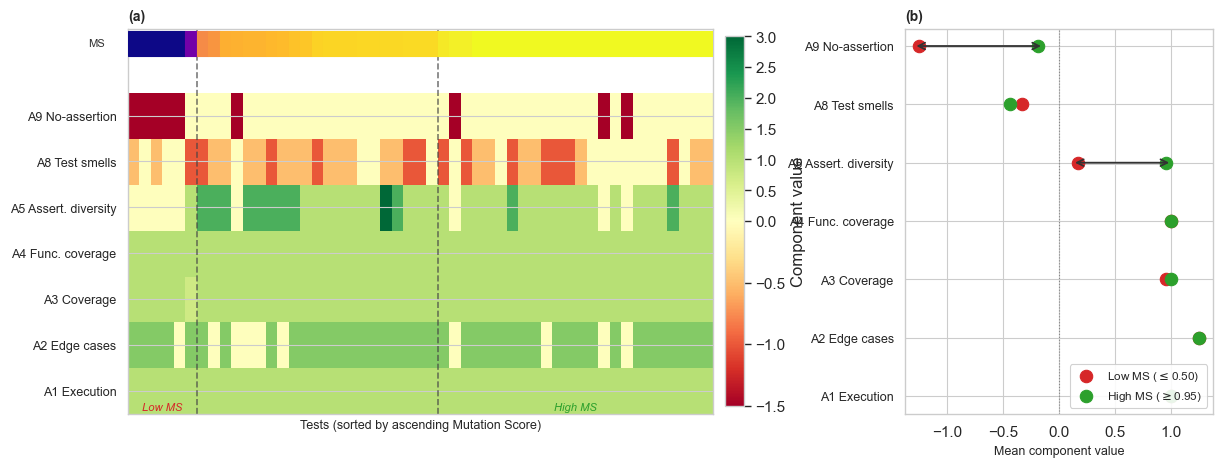

Diagnostic gap per component (|high - low|):
  A1 Execution           low=1.000  high=1.000  gap=0.000
  A2 Edge cases          low=1.250  high=1.250  gap=0.000
  A3 Coverage            low=0.952  high=1.000  gap=0.048
  A4 Func. coverage      low=1.000  high=1.000  gap=0.000
  A5 Assert. diversity   low=0.167  high=0.958  gap=0.792
  A8 Test smells         low=-0.333  high=-0.438  gap=0.104
  A9 No-assertion        low=-1.250  high=-0.188  gap=1.062


In [7]:
import matplotlib.gridspec as gridspec

MAX_ASSERT = 3

def get_components(e):
    at = e.get('assert_types') or []
    ts = e.get('test_smells') or []
    ft = e.get('functions_tested') or 0
    tf = e.get('total_functions') or 0
    return {
        'A1 Execution': 1.0 if e.get('baseline_passed') else 0.0,
        'A2 Edge cases': 1.5 if e.get('edge_case_found') else 0.0,
        'A3 Coverage': float(e.get('coverage') or 0),
        'A4 Func. coverage': (ft / tf) if ft and tf else 0.0,
        'A5 Assert. diversity': min(len(at) / MAX_ASSERT, 1.0) * 3.0,
        'A8 Test smells': len(ts) * -0.5,
        'A9 No-assertion': -1.5 if len(at) == 0 else 0.0,
    }

df_raw = pd.read_json("final_dataset_tqs_final.json")
df_raw = df_raw.dropna(subset=["mutation_score"]).copy()
df_raw = df_raw.sort_values("mutation_score").reset_index(drop=True)

comp_names = list(get_components(df_raw.iloc[0].to_dict()).keys())
comp_matrix = np.array([
    list(get_components(row.to_dict()).values())
    for _, row in df_raw.iterrows()
]).T   # shape: (n_components, n_tests)

ms_vals = df_raw["mutation_score"].values
low_mask  = ms_vals <= 0.50
high_mask = ms_vals >= 0.95

mean_low  = comp_matrix[:, low_mask].mean(axis=1)
mean_high = comp_matrix[:, high_mask].mean(axis=1)

# ── Layout ──────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 5))
gs  = gridspec.GridSpec(1, 2, width_ratios=[2, 1], wspace=0.35)
ax_heat = fig.add_subplot(gs[0])
ax_db   = fig.add_subplot(gs[1])

# ── Left: Heatmap components × tests (sorted by MS) ─────────────────
from matplotlib.colors import TwoSlopeNorm
norm = TwoSlopeNorm(vmin=-1.5, vcenter=0, vmax=3.0)
im = ax_heat.imshow(comp_matrix, aspect="auto", cmap="RdYlGn",
                    norm=norm, interpolation="nearest")

plt.colorbar(im, ax=ax_heat, fraction=0.03, pad=0.02, label="Component value")

ax_heat.set_yticks(range(len(comp_names)))
ax_heat.set_yticklabels(comp_names, fontsize=9)
ax_heat.set_xlabel("Tests (sorted by ascending Mutation Score)", fontsize=9)

# MS colorbar on top
ms_bar_y = len(comp_names) + 0.3
for j, ms in enumerate(ms_vals):
    ax_heat.add_patch(plt.Rectangle((j - 0.5, ms_bar_y), 1, 0.55,
                                    color=plt.cm.plasma(ms), zorder=3))
ax_heat.set_ylim(-0.5, ms_bar_y + 0.6)
ax_heat.text(-2.5, ms_bar_y + 0.27, "MS", fontsize=8, va="center", ha="right",
             color="#333333")

# Vertical separator low / high zone
n_low = low_mask.sum()
n_high = high_mask.sum()
ax_heat.axvline(n_low - 0.5, color="#444", lw=1.2, linestyle="--", alpha=0.7)
ax_heat.axvline(len(ms_vals) - n_high - 0.5, color="#444",
                lw=1.2, linestyle="--", alpha=0.7)
ax_heat.text(n_low / 2 - 0.5, -0.42, "Low MS", ha="center",
             fontsize=8, color=COLOR_LOW, style="italic")
ax_heat.text(len(ms_vals) - n_high / 2 - 0.5, -0.42, "High MS", ha="center",
             fontsize=8, color=COLOR_HIGH, style="italic")

ax_heat.set_xticks([])
ax_heat.set_title("(a)", loc="left", fontsize=10, fontweight="bold")

# ── Right: Dumbbell chart mean component low vs high ─────────────────
y_pos = np.arange(len(comp_names))

for i, (lo, hi) in enumerate(zip(mean_low, mean_high)):
    ax_db.plot([lo, hi], [i, i], color="#cccccc", lw=2, zorder=1)
    ax_db.scatter(lo, i, color=COLOR_LOW,  s=80, zorder=3,
                  label="Low MS ($\\leq$0.50)" if i == 0 else "")
    ax_db.scatter(hi, i, color=COLOR_HIGH, s=80, zorder=3,
                  label="High MS ($\\geq$0.95)" if i == 0 else "")

ax_db.set_yticks(y_pos)
ax_db.set_yticklabels(comp_names, fontsize=9)
ax_db.axvline(0, color="#888888", lw=0.8, linestyle=":")
ax_db.set_xlabel("Mean component value", fontsize=9)
ax_db.legend(loc="lower right", fontsize=8.5, framealpha=0.9)
ax_db.set_title("(b)", loc="left", fontsize=10, fontweight="bold")

# Highlight diverging components
for i, name in enumerate(comp_names):
    gap = abs(mean_high[i] - mean_low[i])
    if gap > 0.5:
        ax_db.annotate("", xy=(mean_high[i] + 0.05, i),
                       xytext=(mean_low[i] - 0.05, i),
                       arrowprops=dict(arrowstyle="<->",
                                       color="#333333", lw=1.3))

plt.savefig("fig6_diagnostic.pdf", dpi=300, bbox_inches="tight")
plt.show()

print("Diagnostic gap per component (|high - low|):")
for name, lo, hi in zip(comp_names, mean_low, mean_high):
    print("  {:<22} low={:.3f}  high={:.3f}  gap={:.3f}".format(
        name, lo, hi, abs(hi - lo)))


## Quality Issues Invisible to Mutation Score

Among tests with high mutation score (MS >= 0.90), what quality problems does TQS detect that mutation score cannot?

Even tests that pass mutation testing may still carry structural weaknesses: missing assertion diversity, test smells, or absent edge-case coverage. The percentage-based breakdown below quantifies how often each issue occurs in the high-MS group (n=35), showing that **71.4% have at least one quality problem invisible to mutation score**.

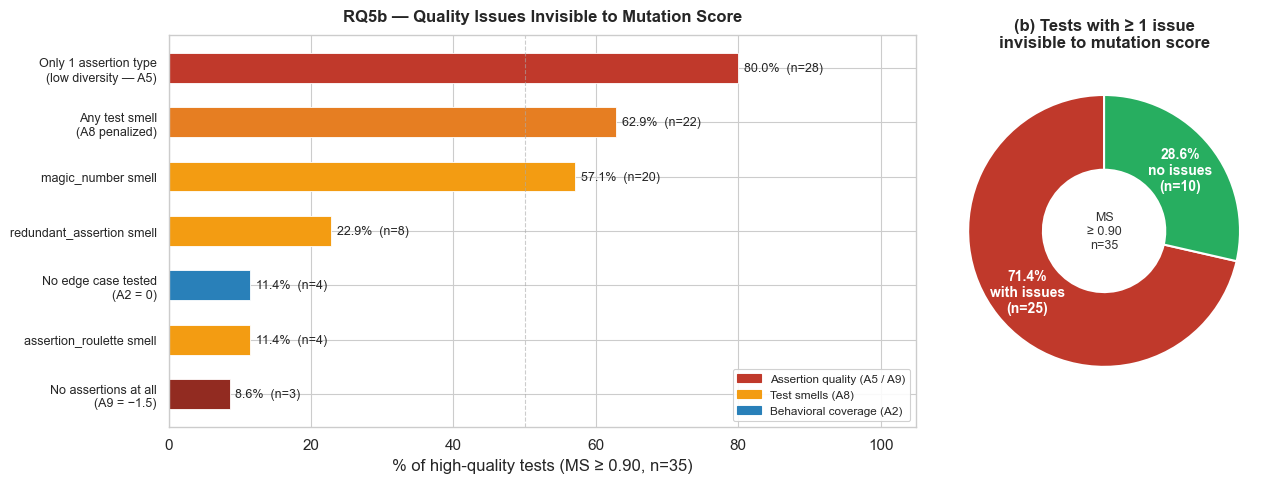

High MS (>=0.90) n=35
At least one issue: 25 (71.4%)
No issues:          10 (28.6%)

  Only 1 assertion type (low diversity — A5) 80.0%  (n=28)
  Any test smell (A8 penalized)              62.9%  (n=22)
  magic_number smell                         57.1%  (n=20)
  redundant_assertion smell                  22.9%  (n=8)
  No edge case tested (A2 = 0)               11.4%  (n=4)
  assertion_roulette smell                   11.4%  (n=4)
  No assertions at all (A9 = −1.5)           8.6%  (n=3)


In [9]:
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

df_raw = pd.read_json("final_dataset_tqs_final.json")
high = df_raw[df_raw["mutation_score"] >= 0.90].copy()
n = len(high)

high["assert_count"] = high["assert_types"].apply(
    lambda x: len(x) if isinstance(x, list) else 0)
high["smell_count"] = high["test_smells"].apply(
    lambda x: len(x) if isinstance(x, list) else 0)
high["has_magic"]    = high["test_smells"].apply(
    lambda x: "magic_number" in x if isinstance(x, list) else False)
high["has_redund"]   = high["test_smells"].apply(
    lambda x: "redundant_assertion" in x if isinstance(x, list) else False)
high["has_roulette"] = high["test_smells"].apply(
    lambda x: "assertion_roulette" in x if isinstance(x, list) else False)

problems = {
    "Only 1 assertion type\n(low diversity — A5)":
        (high["assert_count"] == 1).sum(),
    "Any test smell\n(A8 penalized)":
        (high["smell_count"] > 0).sum(),
    "magic_number smell":
        high["has_magic"].sum(),
    "redundant_assertion smell":
        high["has_redund"].sum(),
    "No edge case tested\n(A2 = 0)":
        (~high["edge_case_found"].fillna(False)).sum(),
    "assertion_roulette smell":
        high["has_roulette"].sum(),
    "No assertions at all\n(A9 = −1.5)":
        (high["assert_count"] == 0).sum(),
}

labels = list(problems.keys())
counts = list(problems.values())
pcts   = [c / n * 100 for c in counts]

# Color: assertion quality = red tones; smells = orange; edge = blue
colors = [
    "#c0392b",   # only 1 assert type
    "#e67e22",   # any smell
    "#f39c12",   # magic_number
    "#f39c12",   # redundant_assertion
    "#2980b9",   # no edge case
    "#f39c12",   # assertion_roulette
    "#922b21",   # no assertions at all
]

# Ordered by pct descending
order = sorted(range(len(pcts)), key=lambda i: pcts[i], reverse=True)
labels_o = [labels[i] for i in order]
pcts_o   = [pcts[i]   for i in order]
colors_o = [colors[i] for i in order]

fig, axes = plt.subplots(1, 2, figsize=(13, 5),
                         gridspec_kw={"width_ratios": [2.2, 1]})
ax_bar, ax_pie = axes

# ── Left: horizontal bar chart ─────────────────────────────────────
y = np.arange(len(labels_o))
bars = ax_bar.barh(y, pcts_o, color=colors_o, height=0.55,
                   edgecolor="white", linewidth=0.6)

for bar, pct, cnt in zip(bars, pcts_o, [counts[i] for i in order]):
    ax_bar.text(pct + 0.8, bar.get_y() + bar.get_height() / 2,
                "{:.1f}%  (n={})".format(pct, int(cnt)),
                va="center", fontsize=9)

ax_bar.set_yticks(y)
ax_bar.set_yticklabels(labels_o, fontsize=9)
ax_bar.set_xlabel("% of high-quality tests (MS ≥ 0.90, n={})".format(n))
ax_bar.set_xlim(0, 105)
ax_bar.axvline(50, color="#aaaaaa", lw=0.8, linestyle="--", alpha=0.6)
ax_bar.invert_yaxis()

# Legend by category
leg_patches = [
    mpatches.Patch(color="#c0392b", label="Assertion quality (A5 / A9)"),
    mpatches.Patch(color="#f39c12", label="Test smells (A8)"),
    mpatches.Patch(color="#2980b9", label="Behavioral coverage (A2)"),
]
ax_bar.legend(handles=leg_patches, loc="lower right", fontsize=8.5,
              framealpha=0.9)
ax_bar.set_title("RQ5b — Quality Issues Invisible to Mutation Score",
                 fontweight="bold", pad=10)

# ── Right: donut — at-least-one vs none ────────────────────────────
at_least_one = int((
    (high["assert_count"] == 0) |
    (~high["edge_case_found"].fillna(False)) |
    (high["smell_count"] > 0)
).sum())
no_problem = n - at_least_one

wedge_sizes  = [at_least_one, no_problem]
wedge_colors = ["#c0392b", "#27ae60"]
wedge_labels = [
    "{:.1f}%\nwith issues\n(n={})".format(at_least_one/n*100, at_least_one),
    "{:.1f}%\nno issues\n(n={})".format(no_problem/n*100, no_problem),
]
wedges, _ = ax_pie.pie(
    wedge_sizes, colors=wedge_colors,
    startangle=90, wedgeprops=dict(width=0.55, edgecolor="white", linewidth=1.5)
)

for wedge, label in zip(wedges, wedge_labels):
    angle = (wedge.theta2 + wedge.theta1) / 2
    x = 0.72 * np.cos(np.radians(angle))
    y_pos2 = 0.72 * np.sin(np.radians(angle))
    ax_pie.text(x, y_pos2, label, ha="center", va="center",
                fontsize=10, fontweight="bold",
                color="white")

ax_pie.text(0, 0, "MS\n≥ 0.90\nn={}".format(n),
            ha="center", va="center", fontsize=9, color="#333333")
ax_pie.set_title("(b) Tests with ≥ 1 issue\ninvisible to mutation score",
                 fontweight="bold", pad=10)

plt.tight_layout()
plt.savefig("fig_quality_gap.pdf", dpi=300, bbox_inches="tight")
plt.show()

print("High MS (>=0.90) n={}".format(n))
print("At least one issue: {} ({:.1f}%)".format(at_least_one, at_least_one/n*100))
print("No issues:          {} ({:.1f}%)".format(no_problem, no_problem/n*100))
print()
for lbl, pct, cnt in zip(labels_o, pcts_o, [counts[i] for i in order]):
    clean = lbl.replace("\n", " ")
    print("  {:<42} {:.1f}%  (n={})".format(clean, pct, int(cnt)))